In [1]:
# %%
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon

In [2]:
# %%
CASE_ID = "bird_212_symmetrical_16_1"

RESULTS_DIR = Path("/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_212_symmetrical_shape_16") / CASE_ID
GEOM_DIR = Path("/home/hschatzle/monte-carlo-selection/data/cases/sweep") / CASE_ID

case_jsonl_path = GEOM_DIR / "generated" / f"{CASE_ID}.jsonl"
shapes_npz_path = GEOM_DIR / "generated" / "shapes_xy.npz"
top10_jsonl_path = RESULTS_DIR / "top10_clusters.jsonl"

N_POINTS_SHAPE = 512
N_POINTS_OCCLUDER = 256
N_ARC = 250
TOP_N = 10

In [3]:
# %%
def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    xy = np.asarray(poly, dtype=float)
    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]
    return xy

def signed_area(xy):
    xy = np.asarray(xy, dtype=float)
    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])
    x = xy[:,0]
    y = xy[:,1]
    return 0.5 * np.sum(x[:-1]*y[1:] - x[1:]*y[:-1])

def ensure_ccw(xy):
    if signed_area(xy) < 0:
        return xy[::-1].copy()
    return xy

def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, float)

    if closed and not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])

    seg = np.diff(xy, axis=0)
    seglen = np.sqrt((seg**2).sum(axis=1))
    cum = np.concatenate([[0], np.cumsum(seglen)])
    total = cum[-1]

    if closed:
        t = np.linspace(0, total, n_points+1)[:-1]
    else:
        t = np.linspace(0, total, n_points)

    x = np.interp(t, cum, xy[:,0])
    y = np.interp(t, cum, xy[:,1])
    return np.column_stack([x,y])

def longest_true_run_circular(flags):
    flags = np.asarray(flags, bool)
    n = len(flags)

    doubled = np.concatenate([flags, flags])

    best = None
    best_len = 0
    start = None

    for i,val in enumerate(doubled):

        if val and start is None:
            start = i

        elif not val and start is not None:

            run = i-start
            if start < n:
                run = min(run,n)
                if run > best_len:
                    best_len = run
                    best = (start,start+run)

            start=None

    return best

def extract_inside_arc(xy, occ_poly):

    inside = np.array(
        [occ_poly.covers(Point(x,y)) for x,y in xy],
        dtype=bool
    )

    run = longest_true_run_circular(inside)

    if run is None:
        return None

    doubled = np.vstack([xy,xy])
    s,e = run

    return doubled[s:e]

In [4]:
# %%
last = json.loads(case_jsonl_path.read_text().splitlines()[-1])

npz_meta = np.load(shapes_npz_path, allow_pickle=True)

print("npz files:", npz_meta.files)
print("base_grid raw:", npz_meta["base_grid"])

baseGrid_case = float(np.asarray(npz_meta["base_grid"]).squeeze())

sil_u = np.asarray(last["shape_contour_xy"], dtype=float)
occ_u = np.asarray(last["occluder_rect_xy"], dtype=float)

sil_px = sil_u * baseGrid_case
occ_px = occ_u * baseGrid_case

print("baseGrid_case:", baseGrid_case)
print("silhouette x-range:", sil_px[:, 0].min(), sil_px[:, 0].max())
print("silhouette y-range:", sil_px[:, 1].min(), sil_px[:, 1].max())
print("occluder x-range:", occ_px[:, 0].min(), occ_px[:, 0].max())
print("occluder y-range:", occ_px[:, 1].min(), occ_px[:, 1].max())

npz files: ['polygons', 'out_files', 'base_grid', 'matlab_1_indexed']
base_grid raw: 256
baseGrid_case: 256.0
silhouette x-range: 9.222251343455634 238.99350468500006
silhouette y-range: 44.58788647498373 167.60353274332186
occluder x-range: 23.521720718606588 100.7817453897326
occluder y-range: 67.33295093460029 111.24950818388595


In [5]:
# %%
occ_px_resampled = resample_contour_arc_length(
    ensure_ccw(occ_px),
    n_points=N_POINTS_OCCLUDER,
    closed=True
)

occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

occ_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])

In [6]:
# %%
with open(top10_jsonl_path) as f:
    first_cluster = json.loads(f.readline())

global_indices = [x["global_index"] for x in first_cluster["shapes"][:TOP_N]]

npz = np.load(shapes_npz_path, allow_pickle=True)
polygons = npz["polygons"]

contours_raw = []

for idx in global_indices:

    xy = polygon_to_xy(polygons[idx])
    xy = ensure_ccw(xy)

    contours_raw.append(xy)

print("Loaded contours:",len(contours_raw))

Loaded contours: 10


In [7]:
# %%
import pandas as pd
import json

TOP_N = 200
TARGET_K = first_cluster["k"]  # should be 9 here

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

rows_shape = read_jsonl(RESULTS_DIR / "shape_to_cluster.jsonl")
df_shape = pd.DataFrame(rows_shape)

def posterior_for_k(resp_top5, target_k):
    for d in resp_top5:
        if int(d["k"]) == int(target_k):
            return float(d["p"])
    return 0.0

df_k = df_shape[df_shape["k_argmax"] == TARGET_K].copy()
df_k["p_target_k"] = df_k["resp_top5"].apply(lambda x: posterior_for_k(x, TARGET_K))
df_k = df_k.sort_values(["p_target_k", "global_index"], ascending=[False, True]).reset_index(drop=True)

print("TARGET_K:", TARGET_K)
print("Total shapes assigned to this cluster:", len(df_k))

selected_df = df_k.head(TOP_N).copy()
global_indices = selected_df["global_index"].astype(int).tolist()

print("Using TOP_N =", TOP_N)
print(selected_df[["global_index", "eligible_row", "p_target_k"]])

TARGET_K: 49
Total shapes assigned to this cluster: 521
Using TOP_N = 200
     global_index  eligible_row  p_target_k
0             236           236    1.000000
1            1225          1225    1.000000
2            4461          4461    1.000000
3            4595          4595    1.000000
4            3021          3021    1.000000
..            ...           ...         ...
195           852           852    0.999900
196          2531          2531    0.999886
197          7779          7779    0.999886
198          1705          1705    0.999882
199          2643          2643    0.999870

[200 rows x 3 columns]


In [8]:
# %%
global_indices = selected_df["global_index"].astype(int).tolist()

npz = np.load(shapes_npz_path, allow_pickle=True)
polygons = npz["polygons"]

contours_raw = []
for idx in global_indices:
    xy = polygon_to_xy(polygons[idx], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    contours_raw.append(xy)

print("Loaded contours:", len(contours_raw))

Loaded contours: 200


In [9]:
print(last.keys())

dict_keys(['ts_utc', 'source_mat', 'category', 'img_id', 'coord_system', 'shape_contour_xy', 'occluder_rect_xy', 'occluder_rect_wh', 'occluder_mode', 'seed', 'shape_bounds', 'plotting', 'placement', 'fs_guided_overlay'])


In [10]:
# %%
seg_idx = np.asarray(last["placement"]["window_indices"], dtype=int)
ref_seg_px = sil_px[seg_idx]

ref_start = np.asarray(last["placement"]["window_start_xy"], dtype=float) * baseGrid_case
ref_end   = np.asarray(last["placement"]["window_end_xy"], dtype=float) * baseGrid_case


def orient_arc_like_reference(arc, ref_start, ref_end):
    d_forward = np.sum((arc[0] - ref_start) ** 2) + np.sum((arc[-1] - ref_end) ** 2)
    d_reverse = np.sum((arc[-1] - ref_start) ** 2) + np.sum((arc[0] - ref_end) ** 2)
    if d_reverse < d_forward:
        return arc[::-1].copy()
    return arc

hidden_arcs = []
inside_counts = []
arc_records = []

for row, c in zip(selected_df.itertuples(index=False), contours_raw):
    c_res = resample_contour_arc_length(c, n_points=N_POINTS_SHAPE, closed=True)
    arc = extract_inside_arc(c_res, occ_poly)

    if arc is None:
        inside_counts.append(0)
        arc_records.append({
            "global_index": int(row.global_index),
            "eligible_row": int(row.eligible_row),
            "p_target_k": float(row.p_target_k),
            "inside_len": 0,
            "arc_extracted": False,
        })
        continue

    arc = orient_arc_like_reference(arc, ref_start, ref_end)
    inside_len = len(arc)

    inside_counts.append(inside_len)
    hidden_arcs.append(arc)

    arc_records.append({
        "global_index": int(row.global_index),
        "eligible_row": int(row.eligible_row),
        "p_target_k": float(row.p_target_k),
        "inside_len": int(inside_len),
        "arc_extracted": True,
    })

print("inside arc lengths:", inside_counts)
print("n extracted arcs:", len(hidden_arcs))

# optional diagnostic table
arc_df = pd.DataFrame(arc_records)
display(arc_df)

inside arc lengths: [64, 35, 81, 65, 58, 56, 51, 29, 50, 41, 54, 54, 49, 60, 31, 46, 59, 53, 37, 37, 46, 54, 56, 40, 54, 53, 61, 58, 50, 66, 47, 29, 47, 56, 60, 54, 44, 49, 37, 43, 45, 71, 56, 26, 44, 50, 53, 43, 73, 82, 57, 70, 69, 41, 69, 60, 90, 49, 30, 39, 53, 40, 55, 59, 39, 67, 61, 42, 86, 80, 44, 56, 41, 71, 48, 30, 48, 66, 71, 40, 47, 32, 42, 34, 54, 36, 41, 36, 68, 47, 57, 53, 53, 60, 50, 44, 50, 24, 39, 43, 47, 40, 90, 63, 44, 73, 73, 59, 61, 35, 38, 60, 42, 42, 48, 44, 49, 60, 76, 47, 62, 37, 31, 54, 51, 53, 59, 59, 43, 49, 87, 68, 40, 36, 84, 55, 30, 61, 28, 65, 53, 47, 62, 55, 36, 29, 74, 44, 64, 36, 48, 47, 60, 72, 29, 45, 29, 54, 41, 74, 48, 35, 56, 58, 52, 30, 43, 39, 70, 60, 49, 78, 65, 59, 64, 72, 62, 39, 29, 40, 39, 67, 44, 60, 51, 62, 57, 70, 60, 66, 66, 45, 57, 35, 40, 56, 38, 71, 68, 43]
n extracted arcs: 200


,global_index,eligible_row,p_target_k,inside_len,arc_extracted
0,236,236,1.000000,64,True
1,1225,1225,1.000000,35,True
2,4461,4461,1.000000,81,True
3,4595,4595,1.000000,65,True
4,3021,3021,1.000000,58,True
...,...,...,...,...,...
195,852,852,0.999900,56,True
196,2531,2531,0.999886,38,True
197,7779,7779,0.999886,71,True
198,1705,1705,0.999882,68,True


In [11]:
# %%
hidden_arcs_resampled = np.stack(
    [resample_contour_arc_length(a, n_points=N_ARC, closed=False) for a in hidden_arcs],
    axis=0
)

mean_hidden_arc = hidden_arcs_resampled.mean(axis=0)

print("hidden_arcs_resampled shape:", hidden_arcs_resampled.shape)

hidden_arcs_resampled shape: (200, 250, 2)


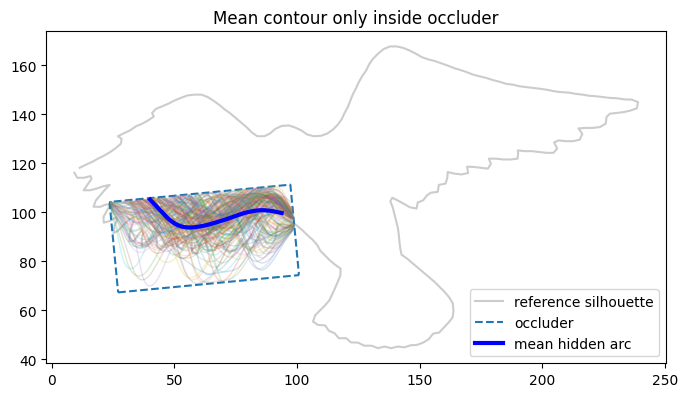

In [12]:
# %%
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="0.8", lw=1.5, label="reference silhouette")
ax.plot(occ_closed[:, 0], occ_closed[:, 1], "--", lw=1.5, label="occluder")

for arc in hidden_arcs_resampled:
    ax.plot(arc[:, 0], arc[:, 1], alpha=0.2, lw=1)

ax.plot(mean_hidden_arc[:, 0], mean_hidden_arc[:, 1], color="blue", lw=3, label="mean hidden arc")

ax.set_aspect("equal")
ax.set_title("Mean contour only inside occluder")
ax.legend()
plt.show()

# Similarity to GT

In [13]:
# %%
# Resample GT segment to same number of points as the mean arc
gt_arc = resample_contour_arc_length(
    ref_seg_px,
    n_points=len(mean_hidden_arc),
    closed=False
)

print("mean_hidden_arc shape:", mean_hidden_arc.shape)
print("gt_arc shape:", gt_arc.shape)

mean_hidden_arc shape: (250, 2)
gt_arc shape: (250, 2)


In [14]:
# %%
def procrustes_rms(A, B):
    """
    RMS after optimal translation + rotation, no scaling.
    Lower = more similar shape.
    """
    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)

    M = B0.T @ A0
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt

    # avoid reflection
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1
        R = U @ Vt

    B_aligned = B0 @ R
    diff = A0 - B_aligned
    return float(np.sqrt((diff ** 2).sum(axis=1).mean()))

def pointwise_rms(A, B):
    """
    Direct pointwise RMS in the shared coordinate frame.
    Lower = more similar.
    """
    diff = A - B
    return float(np.sqrt((diff ** 2).sum(axis=1).mean()))

def chamfer_distance(A, B):
    """
    Symmetric Chamfer distance.
    Lower = more similar.
    """
    D = A[:, None, :] - B[None, :, :]
    D2 = (D ** 2).sum(axis=2)
    return float(D2.min(axis=1).mean() + D2.min(axis=0).mean())

def curvature_profile(xy):
    """
    Turning-angle profile along the arc.
    """
    v = np.diff(xy, axis=0)
    norms = np.linalg.norm(v, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-12)
    v = v / norms

    dot = np.sum(v[:-1] * v[1:], axis=1)
    dot = np.clip(dot, -1.0, 1.0)
    return np.arccos(dot)

def endpoint_error(A, B):
    """
    Mean error at start and end points.
    Lower = better endpoint agreement.
    """
    d1 = np.linalg.norm(A[0] - B[0])
    d2 = np.linalg.norm(A[-1] - B[-1])
    return float((d1 + d2) / 2.0)

In [15]:
# %%
# Compute similarity of mean contour to GT
mean_to_gt_pointwise_rms = pointwise_rms(mean_hidden_arc, gt_arc)
mean_to_gt_procrustes_rms = procrustes_rms(mean_hidden_arc, gt_arc)
mean_to_gt_chamfer = chamfer_distance(mean_hidden_arc, gt_arc)
mean_to_gt_endpoint = endpoint_error(mean_hidden_arc, gt_arc)

curv_mean = curvature_profile(mean_hidden_arc)
curv_gt = curvature_profile(gt_arc)
mean_to_gt_curv_corr = float(np.corrcoef(curv_mean, curv_gt)[0, 1])

print("Mean contour vs GT")
print("pointwise_rms     :", mean_to_gt_pointwise_rms)
print("procrustes_rms    :", mean_to_gt_procrustes_rms)
print("chamfer_distance  :", mean_to_gt_chamfer)
print("endpoint_error    :", mean_to_gt_endpoint)
print("curvature_corr    :", mean_to_gt_curv_corr)

Mean contour vs GT
pointwise_rms     : 11.266795055037578
procrustes_rms    : 4.460659154266375
chamfer_distance  : 171.86707806031507
endpoint_error    : 12.048062786770874
curvature_corr    : 0.11672168056994468


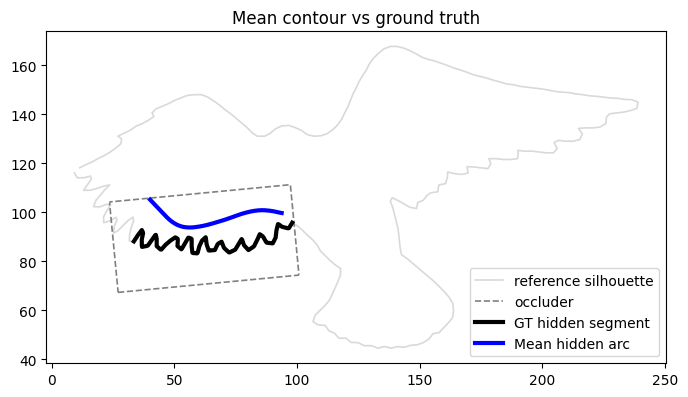

In [16]:
# %%
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="0.85", lw=1.2, label="reference silhouette")
ax.plot(occ_closed[:, 0], occ_closed[:, 1], "--", color="0.5", lw=1.2, label="occluder")

ax.plot(gt_arc[:, 0], gt_arc[:, 1], color="black", lw=3, label="GT hidden segment")
ax.plot(mean_hidden_arc[:, 0], mean_hidden_arc[:, 1], color="blue", lw=3, label="Mean hidden arc")

ax.set_aspect("equal")
ax.set_title("Mean contour vs ground truth")
ax.legend()
plt.show()

# V2

In [17]:
# %%
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon

In [43]:
# %%
CASE_ID = "bird_212_symmetrical_16_1"

RESULTS_DIR = Path("/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_212_symmetrical_shape_16") / CASE_ID
GEOM_DIR = Path("/home/hschatzle/monte-carlo-selection/data/cases/sweep") / CASE_ID

case_jsonl_path = GEOM_DIR / "generated" / f"{CASE_ID}.jsonl"
shapes_npz_path = GEOM_DIR / "generated" / "shapes_xy.npz"
top10_jsonl_path = RESULTS_DIR / "top10_clusters.jsonl"

N_POINTS_SHAPE = 512
N_POINTS_OCCLUDER = 256
N_ARC = 250
TOP_N = 200

In [44]:
# %%
def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    xy = np.asarray(poly, dtype=float)
    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]
    return xy


def signed_area(xy):
    xy = np.asarray(xy, dtype=float)
    if len(xy) < 3:
        return 0.0
    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])


def ensure_ccw(xy):
    xy = np.asarray(xy, dtype=float)
    if signed_area(xy) < 0:
        return xy[::-1].copy()
    return xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)

    if len(xy) < 2:
        raise ValueError("Contour must contain at least 2 points.")

    if closed and not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])

    seg = np.diff(xy, axis=0)
    seglen = np.sqrt((seg ** 2).sum(axis=1))

    keep = seglen > 1e-12
    if not np.all(keep):
        xy = np.vstack([xy[0], xy[1:][keep]])
        seg = np.diff(xy, axis=0)
        seglen = np.sqrt((seg ** 2).sum(axis=1))

    if len(seglen) == 0 or np.sum(seglen) <= 1e-12:
        raise ValueError("Contour has zero total arc length after removing duplicate points.")

    cum = np.concatenate([[0.0], np.cumsum(seglen)])
    total = float(cum[-1])

    if closed:
        t = np.linspace(0.0, total, n_points + 1)[:-1]
    else:
        t = np.linspace(0.0, total, n_points)

    x = np.interp(t, cum, xy[:, 0])
    y = np.interp(t, cum, xy[:, 1])
    return np.column_stack([x, y])


def longest_true_run_circular(flags):
    flags = np.asarray(flags, dtype=bool)
    n = len(flags)

    if n == 0 or not flags.any():
        return None

    doubled = np.concatenate([flags, flags])

    best = None
    best_len = 0
    start = None

    for i, val in enumerate(doubled):
        if val and start is None:
            start = i
        elif (not val) and (start is not None):
            run = i - start
            if start < n:
                run = min(run, n)
                if run > best_len:
                    best_len = run
                    best = (start, start + run)
            start = None

    if start is not None:
        run = len(doubled) - start
        if start < n:
            run = min(run, n)
            if run > best_len:
                best = (start, start + run)

    return best


def extract_inside_arc(xy, occ_poly):
    xy = np.asarray(xy, dtype=float)

    inside = np.array([occ_poly.covers(Point(x, y)) for x, y in xy], dtype=bool)
    run = longest_true_run_circular(inside)

    if run is None:
        return None

    s, e = run
    doubled = np.vstack([xy, xy])
    arc = doubled[s:e]

    if len(arc) < 2:
        return None

    return arc


def orient_arc_like_reference(arc, ref_start, ref_end):
    arc = np.asarray(arc, dtype=float)
    ref_start = np.asarray(ref_start, dtype=float)
    ref_end = np.asarray(ref_end, dtype=float)

    d_forward = np.sum((arc[0] - ref_start) ** 2) + np.sum((arc[-1] - ref_end) ** 2)
    d_reverse = np.sum((arc[-1] - ref_start) ** 2) + np.sum((arc[0] - ref_end) ** 2)

    if d_reverse < d_forward:
        return arc[::-1].copy()
    return arc.copy()


def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def posterior_for_k(resp_top5, target_k):
    for d in resp_top5:
        if int(d["k"]) == int(target_k):
            return float(d["p"])
    return 0.0

In [45]:
# %%
last = json.loads(case_jsonl_path.read_text().splitlines()[-1])

npz_meta = np.load(shapes_npz_path, allow_pickle=True)

print("npz files:", npz_meta.files)
print("base_grid raw:", npz_meta["base_grid"])

baseGrid_case = float(np.asarray(npz_meta["base_grid"]).squeeze())

sil_u = np.asarray(last["shape_contour_xy"], dtype=float)
occ_u = np.asarray(last["occluder_rect_xy"], dtype=float)

sil_px = ensure_ccw(sil_u * baseGrid_case)
occ_px = ensure_ccw(occ_u * baseGrid_case)

print("baseGrid_case:", baseGrid_case)
print("silhouette x-range:", sil_px[:, 0].min(), sil_px[:, 0].max())
print("silhouette y-range:", sil_px[:, 1].min(), sil_px[:, 1].max())
print("occluder x-range:", occ_px[:, 0].min(), occ_px[:, 0].max())
print("occluder y-range:", occ_px[:, 1].min(), occ_px[:, 1].max())

npz files: ['polygons', 'out_files', 'base_grid', 'matlab_1_indexed']
base_grid raw: 256
baseGrid_case: 256.0
silhouette x-range: 9.222251343455634 238.99350468500006
silhouette y-range: 44.58788647498373 167.60353274332186
occluder x-range: 23.521720718606588 100.7817453897326
occluder y-range: 67.33295093460029 111.24950818388595


In [46]:
# %%
occ_px_resampled = resample_contour_arc_length(
    occ_px,
    n_points=N_POINTS_OCCLUDER,
    closed=True
)

occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

occ_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])

In [47]:
# %%
with open(top10_jsonl_path, "r", encoding="utf-8") as f:
    first_cluster = json.loads(f.readline())

TARGET_K = int(first_cluster["k"])

rows_shape = read_jsonl(RESULTS_DIR / "shape_to_cluster.jsonl")
df_shape = pd.DataFrame(rows_shape)

df_k = df_shape[df_shape["k_argmax"] == TARGET_K].copy()
df_k["p_target_k"] = df_k["resp_top5"].apply(lambda x: posterior_for_k(x, TARGET_K))
df_k = df_k.sort_values(["p_target_k", "global_index"], ascending=[False, True]).reset_index(drop=True)

print("TARGET_K:", TARGET_K)
print("Total shapes assigned to this cluster:", len(df_k))

selected_df = df_k.head(TOP_N).copy()
global_indices = selected_df["global_index"].astype(int).tolist()

print("Using TOP_N =", TOP_N)
display(selected_df[["global_index", "eligible_row", "p_target_k"]].head(20))

TARGET_K: 49
Total shapes assigned to this cluster: 521
Using TOP_N = 200


,global_index,eligible_row,p_target_k
0,236,236,1.0
1,1225,1225,1.0
2,4461,4461,1.0
3,4595,4595,1.0
4,3021,3021,1.0
5,1584,1584,1.0
6,632,632,1.0
7,6155,6155,1.0
8,75,75,1.0
9,2756,2756,1.0


In [48]:
# %%
npz = np.load(shapes_npz_path, allow_pickle=True)
polygons = npz["polygons"]

contours_raw = []
for idx in global_indices:
    xy = polygon_to_xy(polygons[idx], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    contours_raw.append(xy)

print("Loaded contours:", len(contours_raw))

Loaded contours: 200


In [49]:
# %%
print(last.keys())
print(last["placement"].keys() if "placement" in last else "no placement key")

dict_keys(['ts_utc', 'source_mat', 'category', 'img_id', 'coord_system', 'shape_contour_xy', 'occluder_rect_xy', 'occluder_rect_wh', 'occluder_mode', 'seed', 'shape_bounds', 'plotting', 'placement', 'fs_guided_overlay'])
dict_keys(['mode', 'center_xy', 'theta_deg', 'base_size_wh', 'applied_size_wh', 'applied_scale', 'window_start_xy', 'window_end_xy', 'window_indices', 'orientation_source', 'sizing_rule'])


In [50]:
# %%
# Derive GT hidden arc directly from silhouette × occluder geometry
sil_res = resample_contour_arc_length(
    sil_px,
    n_points=N_POINTS_SHAPE,
    closed=True
)

gt_hidden_arc = extract_inside_arc(sil_res, occ_poly)

if gt_hidden_arc is None:
    raise ValueError("Could not extract hidden GT arc from silhouette.")

ref_start = gt_hidden_arc[0]
ref_end = gt_hidden_arc[-1]

print("GT hidden arc length:", len(gt_hidden_arc))
print("ref_start:", ref_start)
print("ref_end:", ref_end)

GT hidden arc length: 101
ref_start: [25.44109459 97.49949971]
ref_end: [97.85392223 95.48411761]


In [51]:
# %%
hidden_arcs = []
inside_counts = []
arc_records = []

for row, c in zip(selected_df.itertuples(index=False), contours_raw):
    c_res = resample_contour_arc_length(c, n_points=N_POINTS_SHAPE, closed=True)
    arc = extract_inside_arc(c_res, occ_poly)

    if arc is None:
        inside_counts.append(0)
        arc_records.append({
            "global_index": int(row.global_index),
            "eligible_row": int(row.eligible_row),
            "p_target_k": float(row.p_target_k),
            "inside_len": 0,
            "arc_extracted": False,
        })
        continue

    arc = orient_arc_like_reference(arc, ref_start, ref_end)
    inside_len = len(arc)

    inside_counts.append(inside_len)
    hidden_arcs.append(arc)

    arc_records.append({
        "global_index": int(row.global_index),
        "eligible_row": int(row.eligible_row),
        "p_target_k": float(row.p_target_k),
        "inside_len": int(inside_len),
        "arc_extracted": True,
    })

print("inside arc lengths:", inside_counts)
print("n extracted arcs:", len(hidden_arcs))

arc_df = pd.DataFrame(arc_records)
display(arc_df)

inside arc lengths: [64, 35, 81, 65, 58, 56, 51, 29, 50, 41, 54, 54, 49, 60, 31, 46, 59, 53, 37, 37, 46, 54, 56, 40, 54, 53, 61, 58, 50, 66, 47, 29, 47, 56, 60, 54, 44, 49, 37, 43, 45, 71, 56, 26, 44, 50, 53, 43, 73, 82, 57, 70, 69, 41, 69, 60, 90, 49, 30, 39, 53, 40, 55, 59, 39, 67, 61, 42, 86, 80, 44, 56, 41, 71, 48, 30, 48, 66, 71, 40, 47, 32, 42, 34, 54, 36, 41, 36, 68, 47, 57, 53, 53, 60, 50, 44, 50, 24, 39, 43, 47, 40, 90, 63, 44, 73, 73, 59, 61, 35, 38, 60, 42, 42, 48, 44, 49, 60, 76, 47, 62, 37, 31, 54, 51, 53, 59, 59, 43, 49, 87, 68, 40, 36, 84, 55, 30, 61, 28, 65, 53, 47, 62, 55, 36, 29, 74, 44, 64, 36, 48, 47, 60, 72, 29, 45, 29, 54, 41, 74, 48, 35, 56, 58, 52, 30, 43, 39, 70, 60, 49, 78, 65, 59, 64, 72, 62, 39, 29, 40, 39, 67, 44, 60, 51, 62, 57, 70, 60, 66, 66, 45, 57, 35, 40, 56, 38, 71, 68, 43]
n extracted arcs: 200


,global_index,eligible_row,p_target_k,inside_len,arc_extracted
0,236,236,1.000000,64,True
1,1225,1225,1.000000,35,True
2,4461,4461,1.000000,81,True
3,4595,4595,1.000000,65,True
4,3021,3021,1.000000,58,True
...,...,...,...,...,...
195,852,852,0.999900,56,True
196,2531,2531,0.999886,38,True
197,7779,7779,0.999886,71,True
198,1705,1705,0.999882,68,True


In [52]:
# %%
hidden_arcs = []
inside_counts = []
arc_records = []

for row, c in zip(selected_df.itertuples(index=False), contours_raw):
    c_res = resample_contour_arc_length(c, n_points=N_POINTS_SHAPE, closed=True)
    arc = extract_inside_arc(c_res, occ_poly)

    if arc is None or len(arc) < 2:
        inside_counts.append(0)
        arc_records.append({
            "global_index": int(row.global_index),
            "eligible_row": int(row.eligible_row),
            "p_target_k": float(row.p_target_k),
            "inside_len": 0,
            "arc_extracted": False,
        })
        continue

    hidden_arcs.append(arc)
    inside_counts.append(len(arc))

    arc_records.append({
        "global_index": int(row.global_index),
        "eligible_row": int(row.eligible_row),
        "p_target_k": float(row.p_target_k),
        "inside_len": int(len(arc)),
        "arc_extracted": True,
    })

print("inside arc lengths:", inside_counts)
print("n extracted arcs:", len(hidden_arcs))

arc_df = pd.DataFrame(arc_records)
display(arc_df)

if len(hidden_arcs) == 0:
    raise ValueError("No hidden arcs were extracted.")

# orient consistently using first arc only for direction
ref_arc = hidden_arcs[0]
ref_start = ref_arc[0]
ref_end = ref_arc[-1]

hidden_arcs_oriented = [
    orient_arc_like_reference(arc, ref_start, ref_end)
    for arc in hidden_arcs
]

# recalculate common start/end from the ensemble itself
all_starts = np.stack([arc[0] for arc in hidden_arcs_oriented], axis=0)
all_ends   = np.stack([arc[-1] for arc in hidden_arcs_oriented], axis=0)

common_start = all_starts.mean(axis=0)
common_end   = all_ends.mean(axis=0)

print("common_start:", common_start)
print("common_end  :", common_end)

# resample and explicitly re-anchor endpoints
hidden_arcs_resampled = []
for arc in hidden_arcs_oriented:
    arc_res = resample_contour_arc_length(arc, n_points=N_ARC, closed=False)
    arc_res[0] = common_start
    arc_res[-1] = common_end
    hidden_arcs_resampled.append(arc_res)

hidden_arcs_resampled = np.stack(hidden_arcs_resampled, axis=0)
mean_hidden_arc = hidden_arcs_resampled.mean(axis=0)

# keep mean exactly anchored too
mean_hidden_arc[0] = common_start
mean_hidden_arc[-1] = common_end

print("hidden_arcs_resampled shape:", hidden_arcs_resampled.shape)
print("mean_hidden_arc shape:", mean_hidden_arc.shape)

inside arc lengths: [64, 35, 81, 65, 58, 56, 51, 29, 50, 41, 54, 54, 49, 60, 31, 46, 59, 53, 37, 37, 46, 54, 56, 40, 54, 53, 61, 58, 50, 66, 47, 29, 47, 56, 60, 54, 44, 49, 37, 43, 45, 71, 56, 26, 44, 50, 53, 43, 73, 82, 57, 70, 69, 41, 69, 60, 90, 49, 30, 39, 53, 40, 55, 59, 39, 67, 61, 42, 86, 80, 44, 56, 41, 71, 48, 30, 48, 66, 71, 40, 47, 32, 42, 34, 54, 36, 41, 36, 68, 47, 57, 53, 53, 60, 50, 44, 50, 24, 39, 43, 47, 40, 90, 63, 44, 73, 73, 59, 61, 35, 38, 60, 42, 42, 48, 44, 49, 60, 76, 47, 62, 37, 31, 54, 51, 53, 59, 59, 43, 49, 87, 68, 40, 36, 84, 55, 30, 61, 28, 65, 53, 47, 62, 55, 36, 29, 74, 44, 64, 36, 48, 47, 60, 72, 29, 45, 29, 54, 41, 74, 48, 35, 56, 58, 52, 30, 43, 39, 70, 60, 49, 78, 65, 59, 64, 72, 62, 39, 29, 40, 39, 67, 44, 60, 51, 62, 57, 70, 60, 66, 66, 45, 57, 35, 40, 56, 38, 71, 68, 43]
n extracted arcs: 200


,global_index,eligible_row,p_target_k,inside_len,arc_extracted
0,236,236,1.000000,64,True
1,1225,1225,1.000000,35,True
2,4461,4461,1.000000,81,True
3,4595,4595,1.000000,65,True
4,3021,3021,1.000000,58,True
...,...,...,...,...,...
195,852,852,0.999900,56,True
196,2531,2531,0.999886,38,True
197,7779,7779,0.999886,71,True
198,1705,1705,0.999882,68,True


common_start: [ 40.05347825 105.15943583]
common_end  : [93.7105103  99.69478785]
hidden_arcs_resampled shape: (200, 250, 2)
mean_hidden_arc shape: (250, 2)


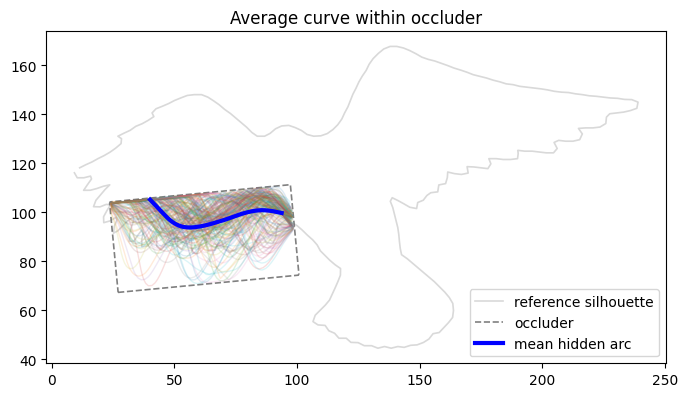

In [53]:
# %%
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="0.85", lw=1.2, label="reference silhouette")
ax.plot(occ_closed[:, 0], occ_closed[:, 1], "--", color="0.5", lw=1.2, label="occluder")

for arc in hidden_arcs_resampled:
    ax.plot(arc[:, 0], arc[:, 1], alpha=0.15, lw=1)

ax.plot(mean_hidden_arc[:, 0], mean_hidden_arc[:, 1], color="blue", lw=3, label="mean hidden arc")

ax.set_aspect("equal")
ax.set_title("Average curve within occluder")
ax.legend()
plt.show()

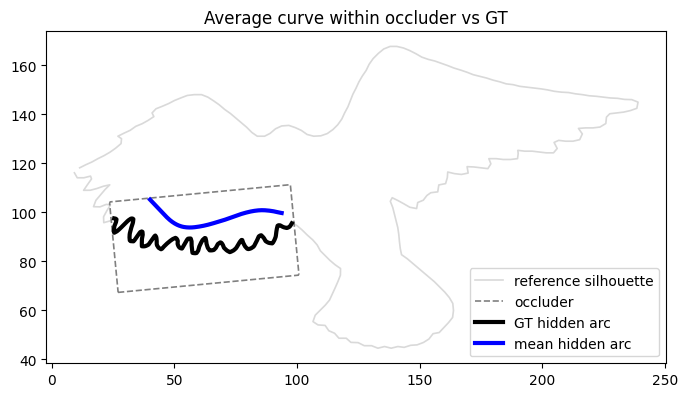

In [54]:
# %%
sil_res = resample_contour_arc_length(sil_px, n_points=N_POINTS_SHAPE, closed=True)
gt_hidden_arc = extract_inside_arc(sil_res, occ_poly)

if gt_hidden_arc is None or len(gt_hidden_arc) < 2:
    raise ValueError("Could not extract GT hidden arc.")

gt_hidden_arc = orient_arc_like_reference(gt_hidden_arc, ref_start, ref_end)
gt_arc = resample_contour_arc_length(gt_hidden_arc, n_points=N_ARC, closed=False)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="0.85", lw=1.2, label="reference silhouette")
ax.plot(occ_closed[:, 0], occ_closed[:, 1], "--", color="0.5", lw=1.2, label="occluder")
ax.plot(gt_arc[:, 0], gt_arc[:, 1], color="black", lw=3, label="GT hidden arc")
ax.plot(mean_hidden_arc[:, 0], mean_hidden_arc[:, 1], color="blue", lw=3, label="mean hidden arc")

ax.set_aspect("equal")
ax.set_title("Average curve within occluder vs GT")
ax.legend()
plt.show()

In [55]:
# %%
from shapely.geometry import LineString, Point, MultiPoint, GeometryCollection

In [56]:
# %%
def extract_intersection_points(geom):
    pts = []

    if geom.is_empty:
        return pts

    if isinstance(geom, Point):
        pts.append(np.array([geom.x, geom.y], dtype=float))

    elif isinstance(geom, MultiPoint):
        for g in geom.geoms:
            pts.append(np.array([g.x, g.y], dtype=float))

    elif isinstance(geom, GeometryCollection):
        for g in geom.geoms:
            pts.extend(extract_intersection_points(g))

    else:
        # ignore overlapping line pieces for now
        pass

    return pts


def dedupe_points(points, tol=1e-6):
    out = []
    for p in points:
        if not any(np.linalg.norm(p - q) < tol for q in out):
            out.append(p)
    return out

In [32]:
# %%
sil_res = resample_contour_arc_length(sil_px, n_points=N_POINTS_SHAPE, closed=True)

gt_line = LineString(np.vstack([sil_res, sil_res[0]]))
occ_boundary = occ_poly.boundary

inter = gt_line.intersection(occ_boundary)
inter_pts = dedupe_points(extract_intersection_points(inter), tol=1e-5)

print("n intersection points:", len(inter_pts))
print("intersection points:")
for p in inter_pts:
    print(p)

n intersection points: 2
intersection points:
[ 43.88892524 201.25705611]
[63.28736885 94.21972608]


In [57]:
# %%
def insert_point_into_closed_polyline(xy, p, tol=1e-6):
    """
    Insert point p into the segment of closed polyline xy that contains it.
    Returns new closed polyline with p explicitly included once.
    xy should NOT repeat the first point at the end.
    """
    xy = np.asarray(xy, dtype=float)
    p = np.asarray(p, dtype=float)

    n = len(xy)
    for i in range(n):
        a = xy[i]
        b = xy[(i + 1) % n]

        ab = b - a
        ap = p - a

        denom = np.dot(ab, ab)
        if denom < tol:
            continue

        t = np.dot(ap, ab) / denom
        proj = a + np.clip(t, 0.0, 1.0) * ab

        if np.linalg.norm(proj - p) < 1e-4 and 0.0 <= t <= 1.0:
            if np.linalg.norm(a - p) < 1e-6 or np.linalg.norm(b - p) < 1e-6:
                return xy.copy()

            return np.vstack([xy[:i+1], p[None, :], xy[i+1:]])

    raise ValueError("Point could not be inserted into polyline.")

In [58]:
# %%
def index_of_point(xy, p, tol=1e-6):
    for i, q in enumerate(xy):
        if np.linalg.norm(q - p) < tol:
            return i
    raise ValueError("Point not found in polyline.")

In [60]:
# %%
def split_closed_contour_between_points(xy, p1, p2):
    """
    xy: open representation of closed contour, shape (N,2), first point not repeated
    p1, p2: points on contour
    Returns two candidate paths between p1 and p2.
    """
    xy2 = insert_point_into_closed_polyline(xy, p1)
    xy2 = insert_point_into_closed_polyline(xy2, p2)

    i1 = index_of_point(xy2, p1)
    i2 = index_of_point(xy2, p2)

    if i1 > i2:
        i1, i2 = i2, i1
        p1, p2 = p2, p1

    path1 = xy2[i1:i2+1]

    wrap = np.vstack([xy2[i2:], xy2[:i1+1]])
    path2 = wrap

    return path1, path2

In [63]:
# %%
def inside_fraction(path, poly):
    flags = np.array([poly.covers(Point(x, y)) for x, y in path], dtype=float)
    return float(flags.mean())


def midpoint_inside_score(path, poly):
    mid = path[len(path)//2]
    return 1.0 if poly.covers(Point(mid[0], mid[1])) else 0.0

In [64]:
# %%
if len(inter_pts) != 2:
    raise ValueError(f"Expected 2 GT/occluder intersections, got {len(inter_pts)}")

p1, p2 = inter_pts

path_a, path_b = split_closed_contour_between_points(sil_res, p1, p2)

frac_a = inside_fraction(path_a, occ_poly)
frac_b = inside_fraction(path_b, occ_poly)

print("inside fraction path_a:", frac_a)
print("inside fraction path_b:", frac_b)

gt_hidden_arc = path_a if frac_a >= frac_b else path_b

print("chosen GT arc length:", len(gt_hidden_arc))
print("GT start:", gt_hidden_arc[0])
print("GT end  :", gt_hidden_arc[-1])

ValueError: Point could not be inserted into polyline.

In [65]:
common_start = gt_hidden_arc[0]
common_end   = gt_hidden_arc[-1]

In [66]:
# %%
hidden_arcs = []

for row, c in zip(selected_df.itertuples(index=False), contours_raw):
    c_res = resample_contour_arc_length(c, n_points=N_POINTS_SHAPE, closed=True)
    arc = extract_inside_arc(c_res, occ_poly)

    if arc is None or len(arc) < 2:
        continue

    arc = orient_arc_like_reference(arc, common_start, common_end)
    hidden_arcs.append(arc)

if len(hidden_arcs) == 0:
    raise ValueError("No hidden arcs were extracted.")

In [67]:
# %%
hidden_arcs_resampled = []
for arc in hidden_arcs:
    arc_res = resample_contour_arc_length(arc, n_points=N_ARC, closed=False)
    arc_res[0] = common_start
    arc_res[-1] = common_end
    hidden_arcs_resampled.append(arc_res)

hidden_arcs_resampled = np.stack(hidden_arcs_resampled, axis=0)
mean_hidden_arc = hidden_arcs_resampled.mean(axis=0)

mean_hidden_arc[0] = common_start
mean_hidden_arc[-1] = common_end

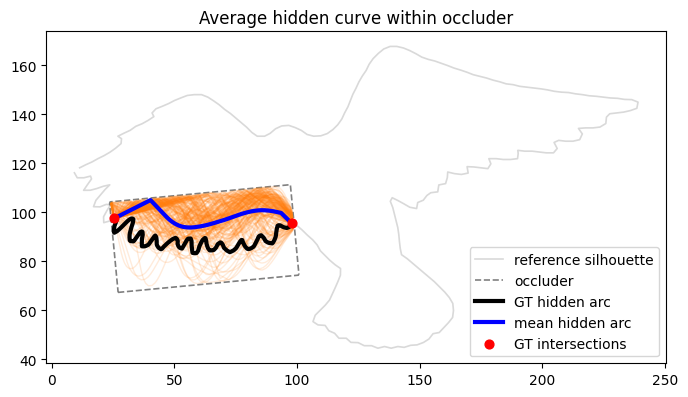

In [68]:
# %%
# Plot GT arc, all extracted within-occluder arcs, and the anchored mean curve

fig, ax = plt.subplots(figsize=(8, 8))

# reference silhouette
ax.plot(
    sil_px[:, 0],
    sil_px[:, 1],
    color="0.85",
    lw=1.2,
    label="reference silhouette",
)

# occluder boundary
ax.plot(
    occ_closed[:, 0],
    occ_closed[:, 1],
    "--",
    color="0.5",
    lw=1.2,
    label="occluder",
)

# all sampled hidden arcs
for arc in hidden_arcs_resampled:
    ax.plot(
        arc[:, 0],
        arc[:, 1],
        alpha=0.15,
        lw=1.0,
        color="tab:orange",
    )

# GT hidden arc
gt_arc_plot = resample_contour_arc_length(
    gt_hidden_arc,
    n_points=N_ARC,
    closed=False,
)

ax.plot(
    gt_arc_plot[:, 0],
    gt_arc_plot[:, 1],
    color="black",
    lw=3,
    label="GT hidden arc",
)

# mean hidden arc
ax.plot(
    mean_hidden_arc[:, 0],
    mean_hidden_arc[:, 1],
    color="blue",
    lw=3,
    label="mean hidden arc",
)

# mark the two GT intersection anchors
ax.scatter(
    [common_start[0], common_end[0]],
    [common_start[1], common_end[1]],
    color="red",
    s=40,
    zorder=5,
    label="GT intersections",
)

ax.set_aspect("equal")
ax.set_title("Average hidden curve within occluder")
ax.legend()
plt.show()

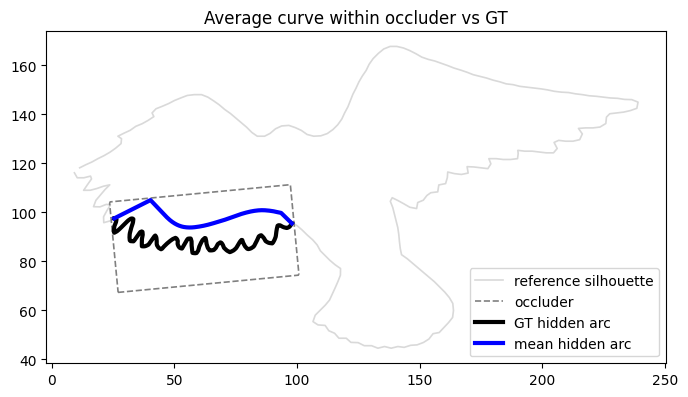

In [69]:
# %%
sil_res = resample_contour_arc_length(sil_px, n_points=N_POINTS_SHAPE, closed=True)
gt_hidden_arc = extract_inside_arc(sil_res, occ_poly)

if gt_hidden_arc is None or len(gt_hidden_arc) < 2:
    raise ValueError("Could not extract GT hidden arc.")

gt_hidden_arc = orient_arc_like_reference(gt_hidden_arc, ref_start, ref_end)
gt_arc = resample_contour_arc_length(gt_hidden_arc, n_points=N_ARC, closed=False)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="0.85", lw=1.2, label="reference silhouette")
ax.plot(occ_closed[:, 0], occ_closed[:, 1], "--", color="0.5", lw=1.2, label="occluder")
ax.plot(gt_arc[:, 0], gt_arc[:, 1], color="black", lw=3, label="GT hidden arc")
ax.plot(mean_hidden_arc[:, 0], mean_hidden_arc[:, 1], color="blue", lw=3, label="mean hidden arc")

ax.set_aspect("equal")
ax.set_title("Average curve within occluder vs GT")
ax.legend()
plt.show()